In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.1' 

%matplotlib widget

import jax
import matplotlib.pyplot as plt
import numpy as np

from temgym_core.constants import energy2wavelength
from temgym_core.components import Detector

import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

3.878288117149014e-07


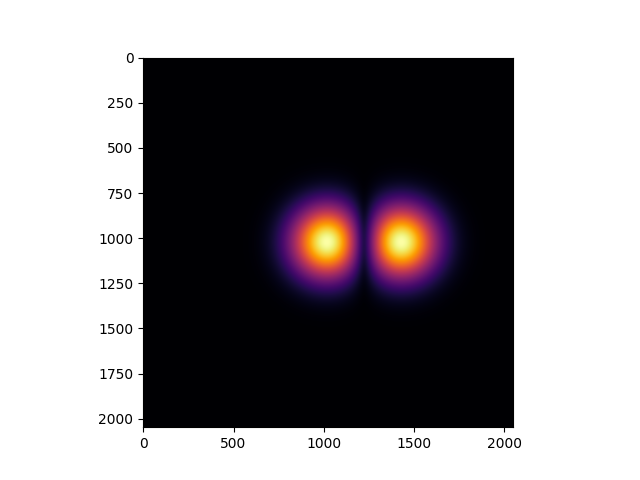

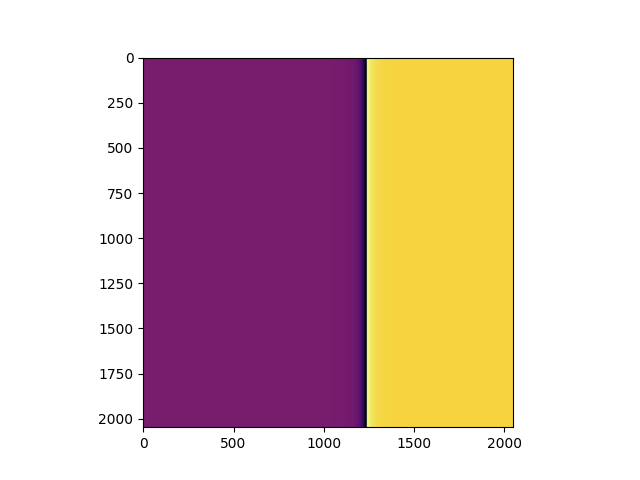

In [ ]:
from temgym_core.gaussian import make_gaussian
from temgym_core.run import run_to_end
from temgym_core.evaluate import evaluate_gaussians_for


def _field_on_grid(ray, grid: Detector) -> np.ndarray:
    field = evaluate_gaussians_for(ray, grid)
    return np.asarray(field)

pixel_size = (1e-8, 1e-8)
shape = (2048, 2048)

detector = Detector(z=0.0, pixel_size=pixel_size, shape=shape)
input_grid = Detector(z=0.0, pixel_size=pixel_size, shape=shape)

wo = 2e-6
voltage = 1e-5
wavelength = energy2wavelength(voltage)
k = 2 * np.pi / wavelength
x01, y01, dx01, dy01, phase1 = 4e-6, 0.0, 0.0, 0.0, 0.213 * k
x02, y02, dx02, dy02, phase2 = 0.0, 0.0, 0.0, 0.0, 0.787 * k

def _make_single_gaussian(x0, y0, dx0, dy0, phase):
    return make_gaussian(
        x=x0,
        y=y0,
        dx=dx0,
        dy=dy0,
        z=0.0,
        voltage=voltage,
        waist_x=wo,
        waist_y=wo,
        amp=1.0,
        phase=phase,
        rcurv_x=jnp.inf,
        rcurv_y=jnp.inf,
    )

rays_in = [
    _make_single_gaussian(x01, y01, dx01, dy01, phase1),
    _make_single_gaussian(x02, y02, dx02, dy02, phase2),
]

analytic_fields = []
input_fields = []

for ray in rays_in:
    propagated = run_to_end(ray, (detector,))
    analytic_fields.append(_field_on_grid(propagated, detector))

analytic_gauss_image = np.sum(analytic_fields, axis=0)

plt.figure()
plt.imshow(np.abs(analytic_gauss_image), cmap='inferno')

plt.figure()
plt.imshow(np.round(np.angle(analytic_gauss_image), 4), cmap='inferno')


